# Influence de l'ordre d'ajout et des quantités sur le signal Raman/SERS

## Contexte
Ces manips (**AS026 → AS031**) testent un dosage du **cuivre (Cu²⁺)** dans l'eau par
**SERS** (*Surface-Enhanced Raman Spectroscopy*). Le principe :

| Réactif | Rôle |
|---------|------|
| **NP** | Nanoparticules métalliques = substrat SERS, elles *amplifient* le signal Raman des molécules adsorbées à leur surface. |
| **PAN** | Indicateur (1-(2-pyridylazo)-2-naphtol) qui forme un **complexe coloré avec le Cu²⁺**. C'est ce complexe Cu–PAN qu'on cherche à voir en Raman. |
| **Mg / BRB** | Tampons (contrôle du pH / force ionique). |
| **EDTA** | Chélatant : il *capture* le Cu²⁺ et entre donc en **compétition** avec le PAN → censé éteindre le signal. |
| **PEG** | Agent stabilisant des nanoparticules (évite l'agrégation incontrôlée). |
| **Cu** | L'analyte cible. |

## Ce qu'on cherche à montrer
1. **Ordre d'ajout** : à composition *strictement identique*, l'ordre dans lequel on
   mélange les réactifs change-t-il le signal ? (Important car la cinétique
   d'adsorption sur les NP et la formation du complexe Cu–PAN peuvent dépendre de
   « qui arrive en premier ».)
2. **Quantités** : effet de la dose d'EDTA (titration 0→75 µL), de Mg, de BRB.
3. **Quelles bandes** Raman portent réellement l'information cuivre.

## Méthode (vue d'ensemble)
`composition (Excel)` + `spectres (.txt)` → **prétraitement** (ligne de base + normalisation)
→ on définit un **indicateur scalaire du signal Cu** (`signal_Cu`) → on le compare entre
échantillons selon l'ordre et les quantités, en se référant toujours au **bruit de mesure**
estimé sur des réplicats.

> ⚠️ Beaucoup de comparaisons sont **confondues** (deux choses changent à la fois) :
> on le signale à chaque fois. Une conclusion n'est solide que si *une seule* variable
> diffère entre deux échantillons.


In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import find_peaks

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True,
                     "grid.alpha": .3, "figure.dpi": 110})

ROOT  = os.getcwd()                      # .../Manips (dossier du notebook)
XLSX  = os.path.join(ROOT, "Protocoles_ASO_corrige_tableaux_uL.xlsx")
MANIPS = ["AS026", "AS027", "AS028", "AS029", "AS030", "AS031"]
print("Dossier de travail :", ROOT)

Dossier de travail : /Users/souchaud/Documents/Travail/CitizenSers/02_Spectroscopie/traitement_données/spectroscopie_raman/Manips


## 1. Chargement des compositions

**But.** Construire une table propre `comp` (1 ligne = 1 échantillon) reliant chaque
spectre à sa recette : volumes de chaque réactif (en µL) et **ordre d'ajout** (texte).

**Pourquoi / comment.**
- On lit la feuille **Synthèse** du fichier Excel (`header=2` car les 2 premières lignes
  sont des titres).
- Les volumes sont convertis en nombres ; `PAN = "à vérifier"` (AS031) devient `NaN`.
- **Convention** : un réactif *absent* de la recette est mis à `0` µL. Cela permet de
  filtrer facilement (ex. « tous les échantillons sans EDTA »).
- On crée des **drapeaux booléens** `a_Cu`, `a_EDTA`, `a_BRB` (présence/absence) qui
  serviront à grouper les échantillons.
- La colonne `Ordre d'ajout` (ex. `NP > PEG > Mg > PAN > H2O`) est la variable clé de
  l'analyse d'ordre.


In [2]:
raw = pd.read_excel(XLSX, sheet_name="Synthèse", header=2)
raw = raw[raw["ID"].notna()].copy()

reactifs = ["PEG", "NP", "Mg", "PAN", "Cu", "EDTA", "Ca", "BRB", "H2O"]
comp = raw[["ID", "Feuille", "Ordre d'ajout"] + reactifs + ["Volume total"]].copy()

# volumes -> numerique (PAN "à vérifier" -> NaN), absent -> 0
for c in reactifs:
    comp[c] = pd.to_numeric(comp[c], errors="coerce")
comp[reactifs] = comp[reactifs].fillna({c: 0 for c in reactifs})  # 0 = produit absent

# drapeaux pratiques
comp["a_Cu"]   = comp["Cu"]   > 0
comp["a_EDTA"] = comp["EDTA"] > 0
comp["a_BRB"]  = comp["BRB"]  > 0
comp = comp.set_index("ID")
print(comp.shape[0], "echantillons")
comp[["Feuille", "Ordre d'ajout", "Mg", "Cu", "EDTA", "BRB", "Volume total"]]

29 echantillons


,Feuille,Ordre d'ajout,Mg,Cu,EDTA,BRB,Volume total
ID,,,,,,,
AS026_1,AS026,NP > PEG > Mg > PAN > H2O,208.0,0.0,0.0,0.0,3238
AS026_2,AS026,NP > PEG > Mg > PAN > Cu > H20,416.0,1000.0,0.0,0.0,3446
AS026_3,AS026,NP > PEG > Mg > PAN > H2O,208.0,0.0,0.0,0.0,3238
AS026_4,AS026,NP > PEG > Mg > PAN > Cu > H20,416.0,1000.0,0.0,0.0,3446
AS026_5,AS026,NP > PEG > PAN > Mg > H2O,208.0,0.0,0.0,0.0,3238
AS026_6,AS026,NP > PEG > Mg > PAN > H2O,208.0,0.0,0.0,0.0,3238
AS027_1,AS027,Cu > PEG > NP > Mg > PAN > H2O,200.0,1000.0,0.0,0.0,3230
AS027_2,AS027,PEG > NP > Ca > PAN > H2O,0.0,0.0,0.0,0.0,2230
AS027_3,AS027,H2O > PEG > NP > Mg > H2O,400.0,0.0,0.0,0.0,3400


## 2. Lecture des spectres Raman

**But.** Transformer chaque fichier instrument `.txt` en un couple
(décalage Raman, intensité) exploitable, puis aligner tous les spectres sur une **grille
commune**.

**Pourquoi / comment.**
- Les fichiers sont au format **BWSpec** : un long en-tête `clé;valeur`, puis un tableau
  dont l'en-tête contient `Raman Shift`. Séparateur `;`, **virgule décimale** (format FR).
- **Axe X = décalage Raman (cm⁻¹)** : c'est le décalage d'énergie par rapport au laser
  (532 nm), indépendant du laser → c'est l'axe physiquement pertinent (pas la longueur
  d'onde brute). On ne garde que la plage où il est défini (pixels calibrés).
- **Axe Y = `Dark Subtracted #1`** : l'intensité brute *moins le courant d'obscurité*
  (signal du capteur dans le noir). On retire ce fond instrumental d'emblée.
- `resolve()` gère la numérotation : AS031 est nommé `AS031_01..04` (zéro initial),
  les autres `AS0xx_1..N`.
- **Interpolation sur une grille commune** `GRID` (300–2000 cm⁻¹, pas 2) : chaque spectre
  peut avoir des points X légèrement différents (calibration pixel). Les ramener sur la
  *même* grille est indispensable pour les **comparer point à point**, faire des
  différences, une moyenne ou une PCA.
- Résultat : `S` = matrice `échantillons × cm⁻¹`.


In [3]:
def read_raman(path):
    "Retourne (raman_shift, intensite) du fichier BWSpec."
    with open(path, encoding="latin-1") as f:
        lines = f.readlines()
    hdr = next(i for i, l in enumerate(lines) if "Raman Shift" in l)
    cols = lines[hdr].rstrip(";\n").split(";")
    df = pd.read_csv(path, sep=";", skiprows=hdr + 1, header=None,
                     decimal=",", names=cols + ["_"], engine="python")
    x = pd.to_numeric(df["Raman Shift"], errors="coerce")
    y = pd.to_numeric(df["Dark Subtracted #1"], errors="coerce")
    m = x.notna() & y.notna() & (x != 0)
    return x[m].to_numpy(), y[m].to_numpy()

def resolve(sample_id):
    "Chemin du .txt (gere la numerotation zero-padded de AS031)."
    folder = sample_id.split("_")[0]
    n = sample_id.split("_")[1]
    for cand in (f"{sample_id}.txt", f"{folder}_{int(n):02d}.txt", f"{folder}_{int(n)}.txt"):
        p = os.path.join(ROOT, folder, cand)
        if os.path.exists(p):
            return p
    return None

# grille commune (interpolation) sur la region d'empreinte
GRID = np.arange(300, 2000, 2.0)
spectra = {}      # id -> intensite interpolee sur GRID
missing = []
for sid in comp.index:
    p = resolve(sid)
    if p is None:
        missing.append(sid); continue
    x, y = read_raman(p)
    order = np.argsort(x)
    spectra[sid] = np.interp(GRID, x[order], y[order])

print("Spectres charges :", len(spectra), "/", comp.shape[0])
if missing: print("Introuvables :", missing)
S = pd.DataFrame(spectra, index=GRID).T   # lignes = echantillons, colonnes = cm-1

Spectres charges : 29 / 29


## 3. Prétraitement : ligne de base (modpoly, **comme Ramanalyze**) + normalisation

Un spectre Raman brut = **pics utiles** posés sur un **fond lentement variable**
(fluorescence des molécules/NP, dérive optique). Ce fond fausse toute mesure d'intensité.

**a) Correction de ligne de base — `modpoly` (pybaselines), polynôme d'ordre 5.**
C'est **exactement la méthode de Ramanalyze** (`ramanalyze/data_processing.py` et l'onglet
titration de `Ramanalyze-simple`). Le principe :
- on ajuste un **polynôme** (ordre 5) qui suit le **fond** du spectre de façon itérative :
  à chaque passe, les points situés *au-dessus* du polynôme (les pics) sont rabaissés sur
  l'ajustement, si bien que la courbe finit par épouser le **bas** du spectre (le fond)
  sans monter dans les pics ;
- on soustrait ce fond : `Intensity_corrected = y − baseline`.
- **Comme Ramanalyze, on n'écrête pas** les valeurs négatives résiduelles (pas de
  `clip` à 0) → l'intensité corrigée peut être légèrement négative entre les pics, c'est
  normal.

> Différence avec une version antérieure de ce notebook : on utilisait l'ALS (Eilers).
> On est passé à **modpoly ordre 5** pour que les intensités corrigées soient **identiques
> à celles produites par Ramanalyze**. Pour changer l'ordre, modifier `POLY_ORDER` ci-dessous.

**b) Deux versions du jeu de données, pour deux questions différentes :**
- `S_corr` (corrigé, **non normalisé**) → compare les **amplitudes**. Légitime car
  l'acquisition est *identique* pour tous (intégration 5000 ms, moyenne de 3 spectres).
  C'est la base de l'indicateur `signal_Cu` (§6). **C'est la grandeur que calcule
  Ramanalyze.**
- `S_norm` (normalisé par l'**aire** totale) → compare les **formes** en s'affranchissant
  des variations globales d'intensité. *Spécifique au notebook*, utilisé seulement pour le
  spectre-différence (§6) et la PCA (§9) ; Ramanalyze ne fait pas cette normalisation.

> ⚠️ Aucun **lissage / débruitage** n'est appliqué (ni ici, ni dans Ramanalyze) : seul le
> **fond** est retiré, le bruit haute fréquence est conservé tel quel.


In [4]:
from pybaselines import Baseline   # même bibliothèque que Ramanalyze

POLY_ORDER = 5   # ordre du polynôme modpoly (valeur par défaut de Ramanalyze)

def modpoly_baseline(x, y, poly_order=POLY_ORDER):
    "Ligne de base modpoly (pybaselines) — identique à Ramanalyze."
    baseline, _ = Baseline(x).modpoly(y, poly_order=poly_order)
    return baseline

# Correction identique à Ramanalyze : Intensity_corrected = y - baseline (SANS écrêtage)
S_corr = S.copy()
for sid in S.index:
    y = S.loc[sid].to_numpy()
    S_corr.loc[sid] = y - modpoly_baseline(GRID, y)

# Version normalisée par l'aire (spécifique au notebook : comparaison de FORMES en §6/§9)
area = S_corr.sum(axis=1).replace(0, np.nan)
S_norm = S_corr.div(area, axis=0)
print(f"Prétraitement OK — baseline modpoly ordre {POLY_ORDER} (comme Ramanalyze) :", S_corr.shape)

Prétraitement OK — baseline modpoly ordre 5 (comme Ramanalyze) : (29, 850)


## 4. Vue d'ensemble des spectres

**But.** Inspection visuelle de tous les spectres, regroupés par manip, *avant* toute
mesure chiffrée — pour repérer la qualité des données, les bandes dominantes, les
échantillons aberrants.

**Lecture.** Les spectres d'une même manip sont **empilés avec un décalage vertical**
(*offset*) pour ne pas se superposer : l'axe Y n'est donc pas quantitatif ici, on regarde
seulement *où* sont les pics et *lesquels* changent d'une recette à l'autre.


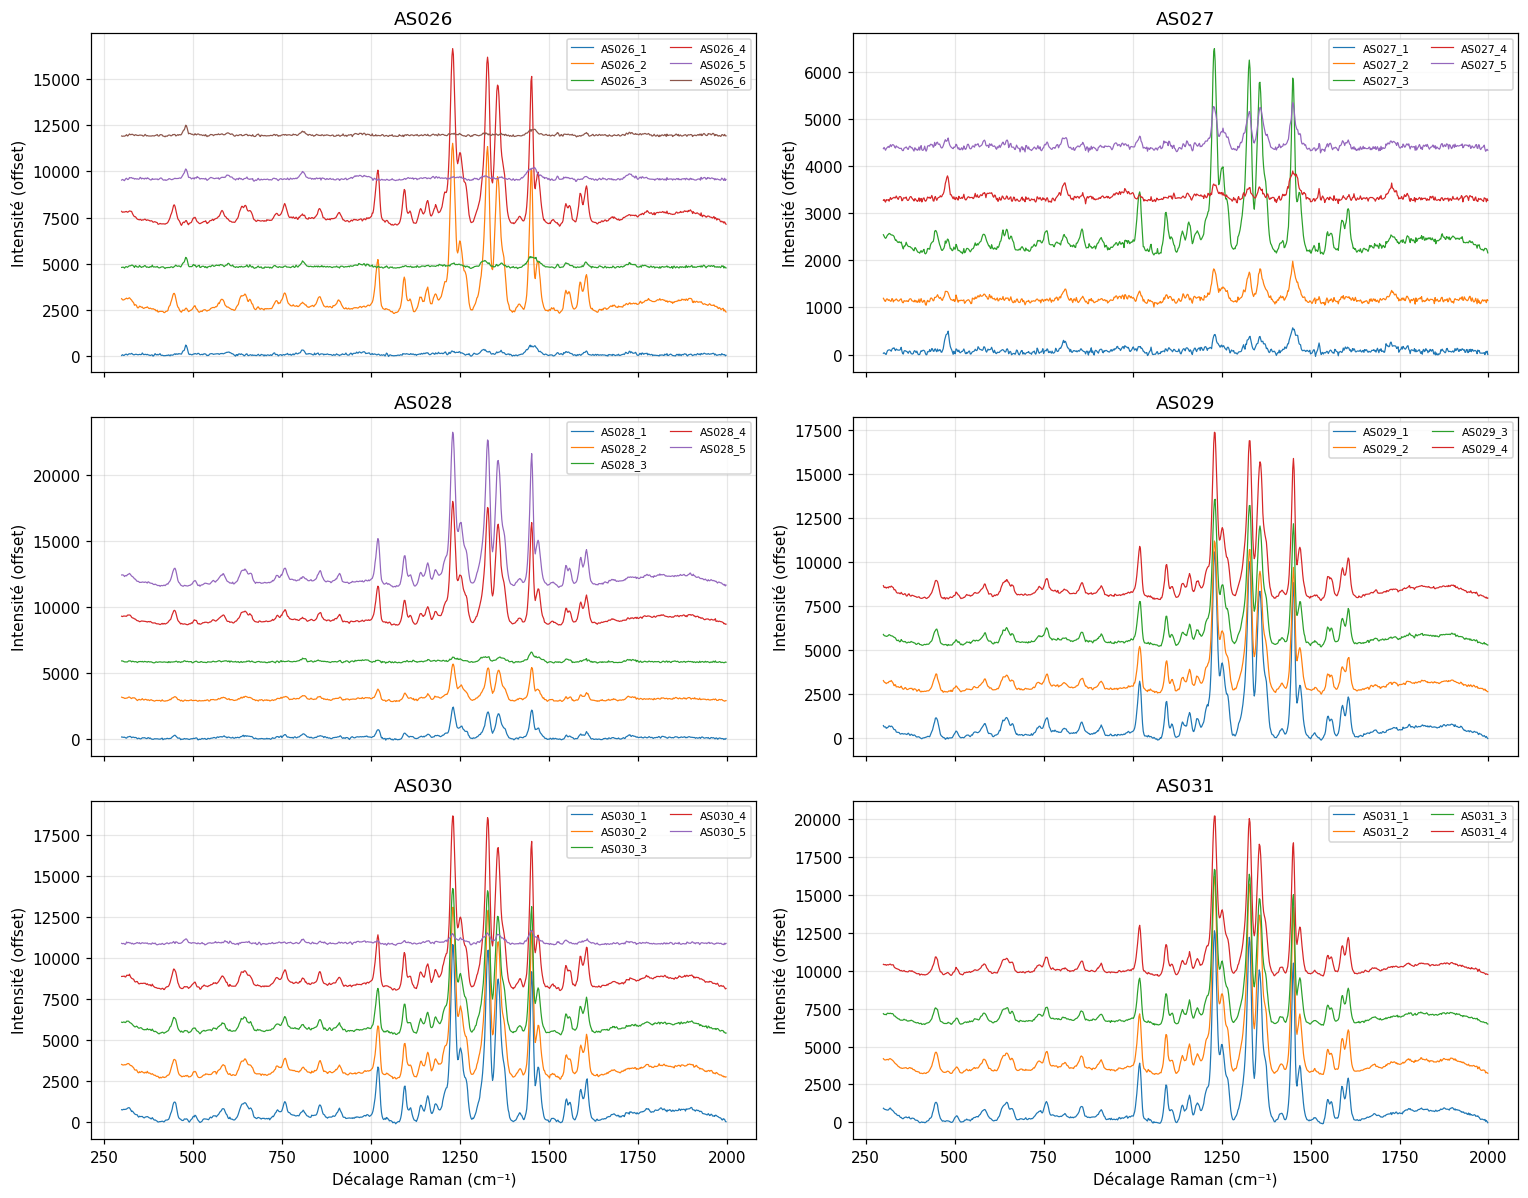

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
for ax, mp in zip(axes.ravel(), MANIPS):
    ids = comp.index[comp["Feuille"] == mp]
    off = 0
    step = S_corr.loc[ids].max().max() * 0.25
    for sid in ids:
        ax.plot(GRID, S_corr.loc[sid] + off, lw=.8, label=sid)
        off += step
    ax.set_title(mp); ax.legend(fontsize=7, ncol=2); ax.set_ylabel("Intensité (offset)")
axes[-1, 0].set_xlabel("Décalage Raman (cm⁻¹)"); axes[-1, 1].set_xlabel("Décalage Raman (cm⁻¹)")
plt.tight_layout(); plt.show()

## 5. Répétabilité instrumentale (le « mètre-étalon »)

**But.** Mesurer le **bruit** : de combien deux mesures *censées être identiques* diffèrent.
C'est la référence indispensable — un écart d'ordre/quantité n'est **interprétable que
s'il dépasse ce bruit**.

**Pourquoi ces 3 échantillons.** `AS026_1`, `AS026_3`, `AS026_6` ont **exactement** la
même recette ET le même ordre (`NP > PEG > Mg > PAN > H2O`, sans Cu) : ce sont de vrais
**réplicats**. Toute différence entre eux ne vient *que* de la variabilité de
préparation + mesure.

**Indicateurs.**
- **Corrélation** entre réplicats (proche de 1 = spectres très semblables).
- **CV** (coefficient de variation = σ/moyenne, en %) point par point : le CV médian
  résume le niveau de bruit relatif. Une différence dont l'effet relatif est inférieur à
  ce CV n'est pas significative.

> Sur ces données le bruit est **élevé** (CV médian ≈ 36 %) : à garder en tête, beaucoup
> d'effets « visibles » sur un seul couple d'échantillons peuvent n'être que du bruit.


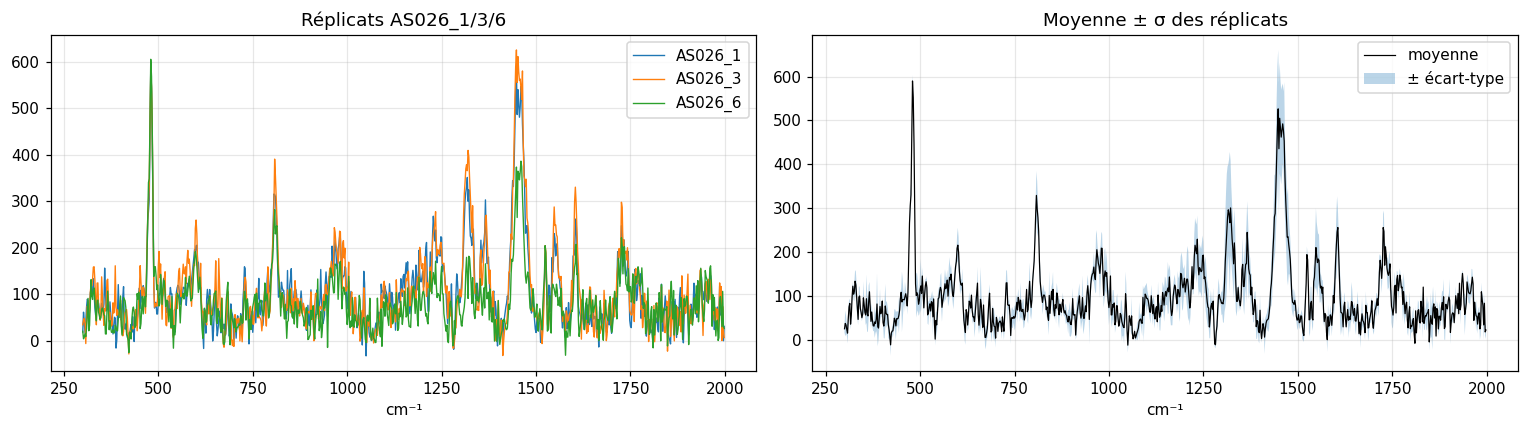

Corrélation entre réplicats :
          AS026_1  AS026_3  AS026_6
AS026_1   1.0000   0.9281   0.8320
AS026_3   0.9281   1.0000   0.8175
AS026_6   0.8320   0.8175   1.0000

CV médian sur la bande 400-1600 cm⁻¹ : 30.8 %  (≈ bruit de mesure)


In [6]:
rep = ["AS026_1", "AS026_3", "AS026_6"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
for sid in rep:
    a1.plot(GRID, S_corr.loc[sid], lw=.9, label=sid)
a1.legend(); a1.set_title("Réplicats AS026_1/3/6"); a1.set_xlabel("cm⁻¹")

M = S_corr.loc[rep]
cv = (M.std(axis=0) / M.mean(axis=0).replace(0, np.nan))
a2.plot(GRID, M.mean(axis=0), 'k', lw=.8, label="moyenne")
a2.fill_between(GRID, M.mean(axis=0) - M.std(axis=0), M.mean(axis=0) + M.std(axis=0),
                alpha=.3, label="± écart-type")
a2.legend(); a2.set_title("Moyenne ± σ des réplicats"); a2.set_xlabel("cm⁻¹")
plt.tight_layout(); plt.show()

# matrice de correlation entre replicats
corr = np.corrcoef(M.to_numpy())
print("Corrélation entre réplicats :\n",
      pd.DataFrame(corr, index=rep, columns=rep).round(4))
print(f"\nCV médian sur la bande 400-1600 cm⁻¹ : "
      f"{np.nanmedian(cv[(GRID>400)&(GRID<1600)])*100:.1f} %  (≈ bruit de mesure)")

## 6. Quelles bandes répondent au cuivre ? (définition de l'indicateur)

**But.** Identifier, *à partir des données*, la ou les bandes Raman qui apparaissent quand
le Cu est présent, puis en faire un **indicateur scalaire** `signal_Cu` réutilisable
partout.

**Méthode — spectre différence.**
- On calcule `moyenne(spectres AVEC Cu) − moyenne(spectres SANS Cu)` (sur les spectres
  *normalisés*, pour comparer des formes).
- Les **bosses positives** de cette différence = bandes qui *augmentent* avec le cuivre →
  signature du complexe Cu–PAN exalté par les NP.
- `find_peaks` repère le pic dominant ; on définit une **fenêtre-marqueur** `BAND`
  (± 40 cm⁻¹ autour, surlignée en orange).

**Indicateur `signal_Cu`** = aire du spectre *corrigé* (`S_corr`) dans cette fenêtre.
C'est une simple intégrale d'intensité : grand = beaucoup de complexe Cu–PAN détecté.

> Validation : cet indicateur sépare nettement avec-Cu (~10⁵) de sans-Cu (~5·10³) dans le
> tableau §10 → la fenêtre capture bien le cuivre.
>
> ⚠️ La bande est choisie *empiriquement*. Si tu disposes d'une **attribution de bande
> Cu–PAN issue de la littérature**, fixe `BAND = (x1, x2)` à la main ici : l'indicateur
> en sera plus robuste et comparable à d'autres études.


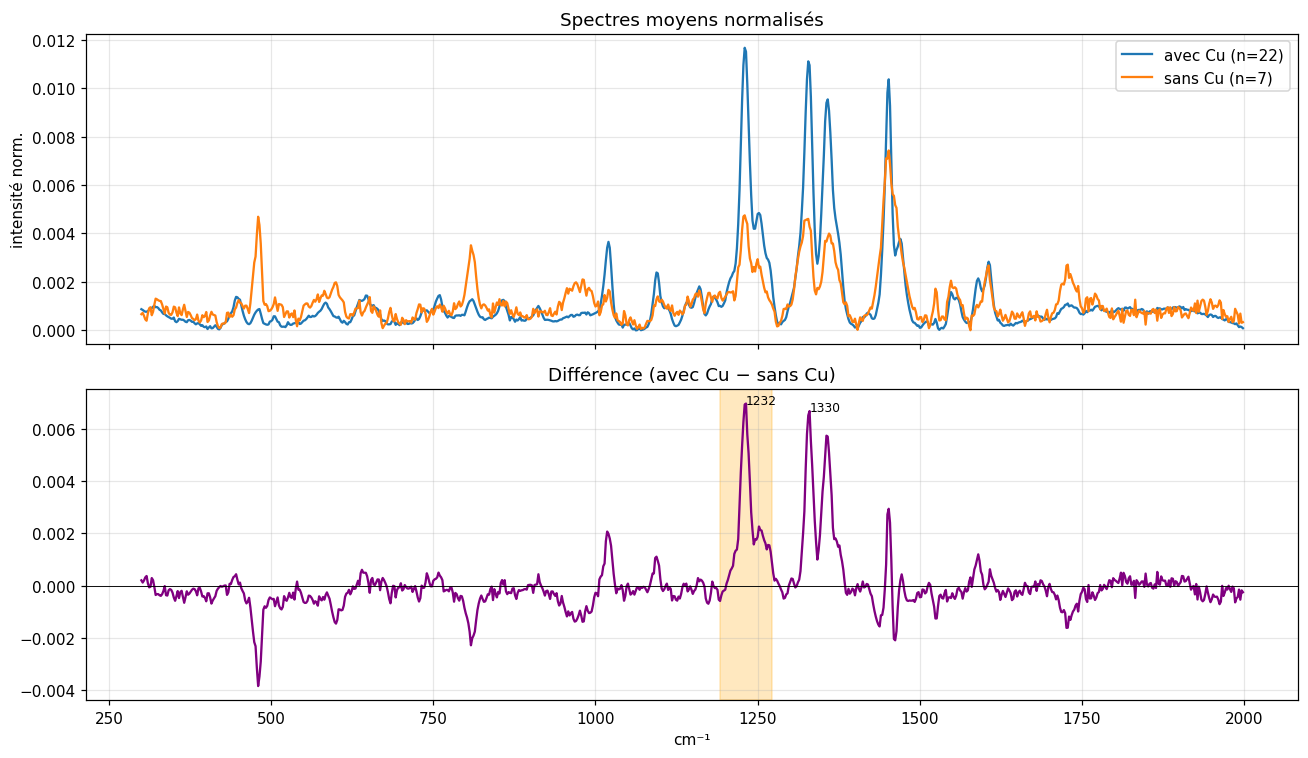

Bande-marqueur Cu retenue : (1192, 1272) cm⁻¹


In [7]:
ids_cu   = comp.index[comp["a_Cu"]  & comp.index.isin(S_norm.index)]
ids_nocu = comp.index[~comp["a_Cu"] & comp.index.isin(S_norm.index)]
diff = S_norm.loc[ids_cu].mean() - S_norm.loc[ids_nocu].mean()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
a1.plot(GRID, S_norm.loc[ids_cu].mean(), label=f"avec Cu (n={len(ids_cu)})")
a1.plot(GRID, S_norm.loc[ids_nocu].mean(), label=f"sans Cu (n={len(ids_nocu)})")
a1.legend(); a1.set_title("Spectres moyens normalisés"); a1.set_ylabel("intensité norm.")
a2.plot(GRID, diff, 'purple'); a2.axhline(0, color='k', lw=.6)
a2.set_title("Différence (avec Cu − sans Cu)"); a2.set_xlabel("cm⁻¹")

# pic le plus marqueur du cuivre
pk, _ = find_peaks(diff.to_numpy(), height=diff.max()*0.5, distance=20)
for i in pk:
    a2.annotate(f"{GRID[i]:.0f}", (GRID[i], diff.iloc[i]), fontsize=8)
band_center = GRID[pk[np.argmax(diff.to_numpy()[pk])]] if len(pk) else 1300
BAND = (band_center - 40, band_center + 40)
a2.axvspan(*BAND, color='orange', alpha=.25)
plt.tight_layout(); plt.show()
print("Bande-marqueur Cu retenue :", tuple(round(b) for b in BAND), "cm⁻¹")

# indicateur = aire corrigee dans la bande-marqueur
sel = (GRID >= BAND[0]) & (GRID <= BAND[1])
signal = S_corr.loc[:, sel].sum(axis=1).rename("signal_Cu")
comp["signal_Cu"] = signal

## 7. Influence de l'ordre d'ajout

**Principe d'interprétation.** Un effet d'ordre n'est *propre* que si **seul l'ordre**
change entre deux échantillons (même réactifs, mêmes volumes). On privilégie donc les
paires « contrôlées ». On compare toujours l'écart observé au **bruit du §5**.

### 7.a — Permutation pure Mg ↔ PAN (composition strictement identique)
`AS026_1` (`…Mg > PAN…`) vs `AS026_5` (`…PAN > Mg…`) : **mêmes** réactifs et **mêmes**
volumes, seul l'ordre Mg/PAN est inversé. C'est la comparaison la plus propre du notebook.
*Note* : ces deux-là sont **sans Cu**, on teste donc l'effet de l'ordre sur le signal de
fond (PAN/NP), pas sur le complexe Cu–PAN.


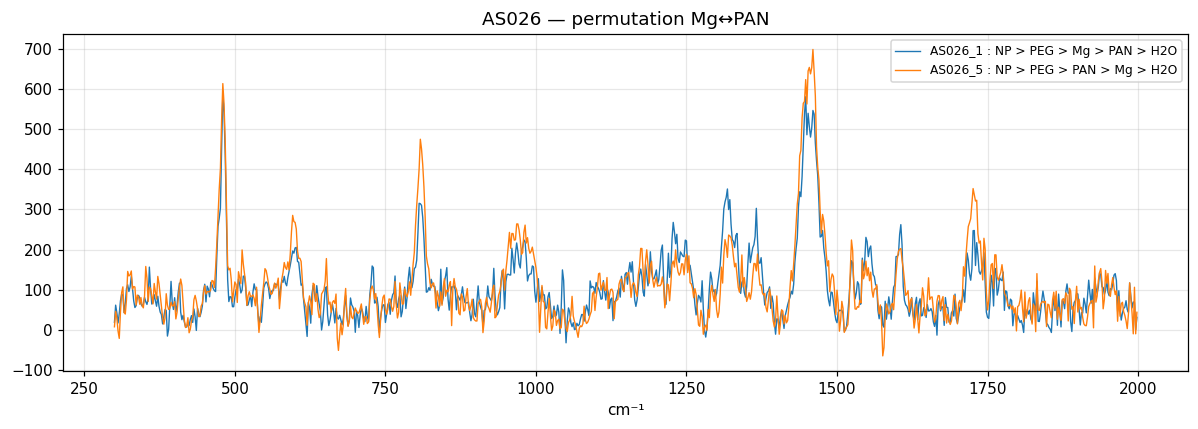

signal_Cu  AS026_1 = 6240 | AS026_5 = 4996  (réf. bruit réplicats ci-dessus)


In [8]:
pair = ["AS026_1", "AS026_5"]
plt.figure(figsize=(11, 4))
for sid in pair:
    plt.plot(GRID, S_corr.loc[sid], lw=.9,
             label=f"{sid} : {comp.loc[sid, 'Ordre d\'ajout']}")
plt.legend(fontsize=8); plt.title("AS026 — permutation Mg↔PAN"); plt.xlabel("cm⁻¹")
plt.tight_layout(); plt.show()
print("signal_Cu  AS026_1 = %.0f | AS026_5 = %.0f  (réf. bruit réplicats ci-dessus)"
      % (signal['AS026_1'], signal['AS026_5']))

### 7.b — Position du cuivre dans la séquence (AS028)

**Design.** Tous les AS028 partagent la **même recette** (Cu 1000, Mg 400, PAN 30, PEG,
NP, H2O 500) ; seule **la position où le Cu est ajouté** varie — du tout début (`Cu` en
1er) à la toute fin (`Cu` en dernier). `AS028_3` ne contient **pas** de Cu → c'est le
**témoin négatif**.

**Pourquoi c'est intéressant.** Si le Cu est introduit *avant* que les NP/PAN soient en
place, il peut se passer autre chose (adsorption, complexation incomplète) que s'il arrive
en dernier sur un système déjà formé. On lit `signal_Cu` en fonction de la position du Cu.


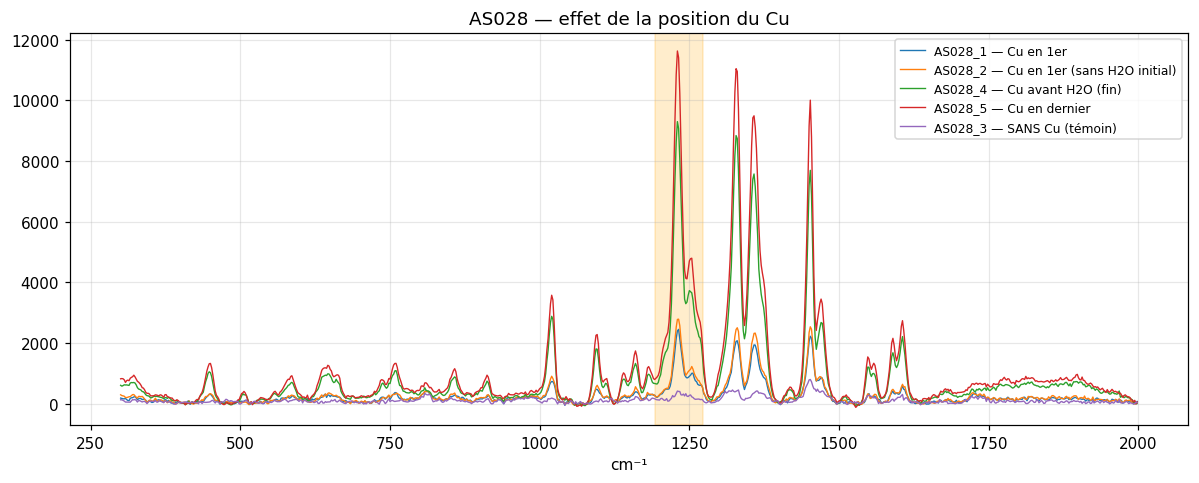

                          Ordre d'ajout      signal_Cu
ID                                                    
AS028_1  Cu > H2O > PEG > NP > Mg > PAN   36739.706822
AS028_2  Cu > PEG > NP > Mg > PAN > H2O   42547.349932
AS028_4  PEG > NP > Mg > PAN > Cu > H2O  138356.553306
AS028_5  PEG > NP > Mg > PAN > H2O > Cu  174999.554137
AS028_3       H2O > PEG > NP > Mg > PAN    8542.365286


In [9]:
order28 = {"AS028_1": "Cu en 1er", "AS028_2": "Cu en 1er (sans H2O initial)",
           "AS028_4": "Cu avant H2O (fin)", "AS028_5": "Cu en dernier",
           "AS028_3": "SANS Cu (témoin)"}
plt.figure(figsize=(11, 4.5))
for sid, lab in order28.items():
    if sid in S_corr.index:
        plt.plot(GRID, S_corr.loc[sid], lw=.9, label=f"{sid} — {lab}")
plt.axvspan(*BAND, color='orange', alpha=.2); plt.legend(fontsize=8)
plt.title("AS028 — effet de la position du Cu"); plt.xlabel("cm⁻¹")
plt.tight_layout(); plt.show()
print(comp.loc[[s for s in order28 if s in comp.index],
               ["Ordre d'ajout", "signal_Cu"]].to_string())

### 7.c — Ordre Cu ↔ BRB (AS029)

- `AS029_1` (`…Cu > BRB`) vs `AS029_2` (`…BRB > Cu`) à **Mg 800 / BRB 100** : ici seul
  l'ordre change → comparaison **propre**.
- `AS029_3` vs `AS029_4` : l'ordre change *mais aussi* le **volume de BRB** (100 vs 500 µL)
  et le Mg. ⚠️ Effet d'ordre **confondu** avec la quantité → on ne peut pas attribuer une
  différence à l'ordre seul.


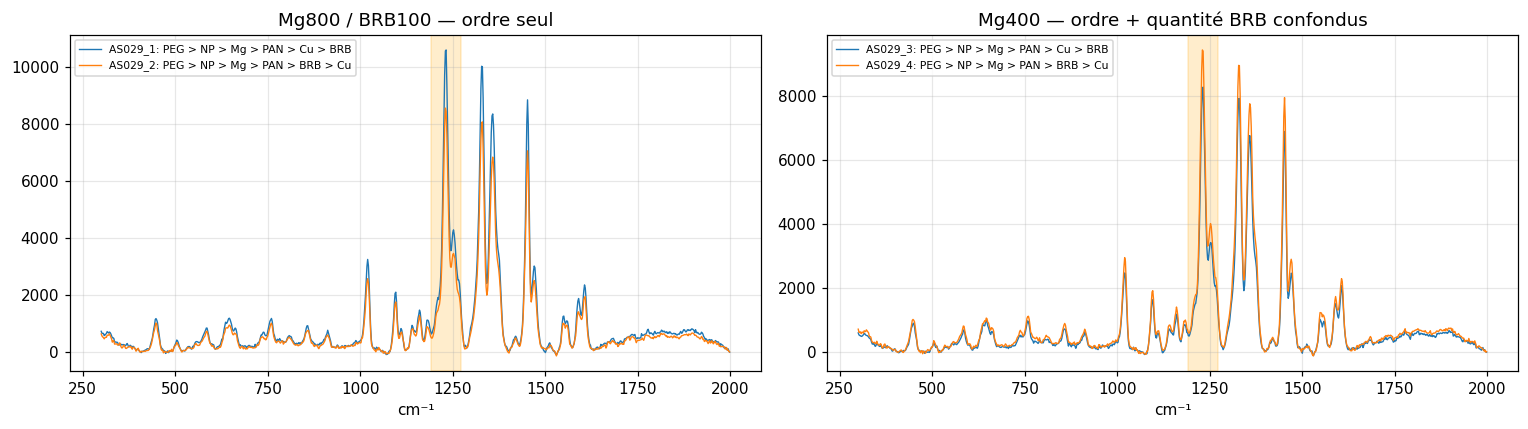

            Mg    BRB                   Ordre d'ajout      signal_Cu
ID                                                                  
AS029_1  800.0  100.0  PEG > NP > Mg > PAN > Cu > BRB  155521.280428
AS029_2  800.0  100.0  PEG > NP > Mg > PAN > BRB > Cu  126885.849100
AS029_3  400.0  100.0  PEG > NP > Mg > PAN > Cu > BRB  123902.607485
AS029_4  400.0  500.0  PEG > NP > Mg > PAN > BRB > Cu  141798.608995


In [10]:
grp = [("AS029_1", "AS029_2"), ("AS029_3", "AS029_4")]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (a, b) in zip(axes, grp):
    for sid in (a, b):
        ax.plot(GRID, S_corr.loc[sid], lw=.9,
                label=f"{sid}: {comp.loc[sid,'Ordre d\'ajout']}")
    ax.axvspan(*BAND, color='orange', alpha=.2); ax.legend(fontsize=7); ax.set_xlabel("cm⁻¹")
axes[0].set_title("Mg800 / BRB100 — ordre seul")
axes[1].set_title("Mg400 — ordre + quantité BRB confondus")
plt.tight_layout(); plt.show()
print(comp.loc[["AS029_1","AS029_2","AS029_3","AS029_4"],
               ["Mg","BRB","Ordre d'ajout","signal_Cu"]].to_string())

## 8. Influence des quantités

### 8.a — Titration EDTA (dose–réponse) — AS030 & AS031

**Design.** À recette Cu constante, on fait varier **uniquement l'EDTA** : 0 / 25 / 50 / 75 µL.
C'est le test **le mieux contrôlé** du jeu de données (une seule variable, 4 niveaux).

**Hypothèse.** L'EDTA chélate le Cu²⁺ et le soustrait au PAN → on s'attend à une
**décroissance** de `signal_Cu` quand l'EDTA augmente. La **courbe dose–réponse**
(`signal_Cu` vs µL d'EDTA) teste cette hypothèse ; sa **pente** quantifie l'efficacité du
chélatant.

**AS030 vs AS031** : même titration mais l'EDTA est ajouté à un moment différent
(AS030 : Cu *puis* EDTA ; AS031 : EDTA *puis* Cu) → comparer les deux courbes dit si
l'ordre Cu/EDTA modifie la compétition.

> On filtre sur la séquence standard `PEG > NP > Mg > …` pour exclure AS030_5
> (ordre PAN/Mg différent) qui fausserait la courbe.


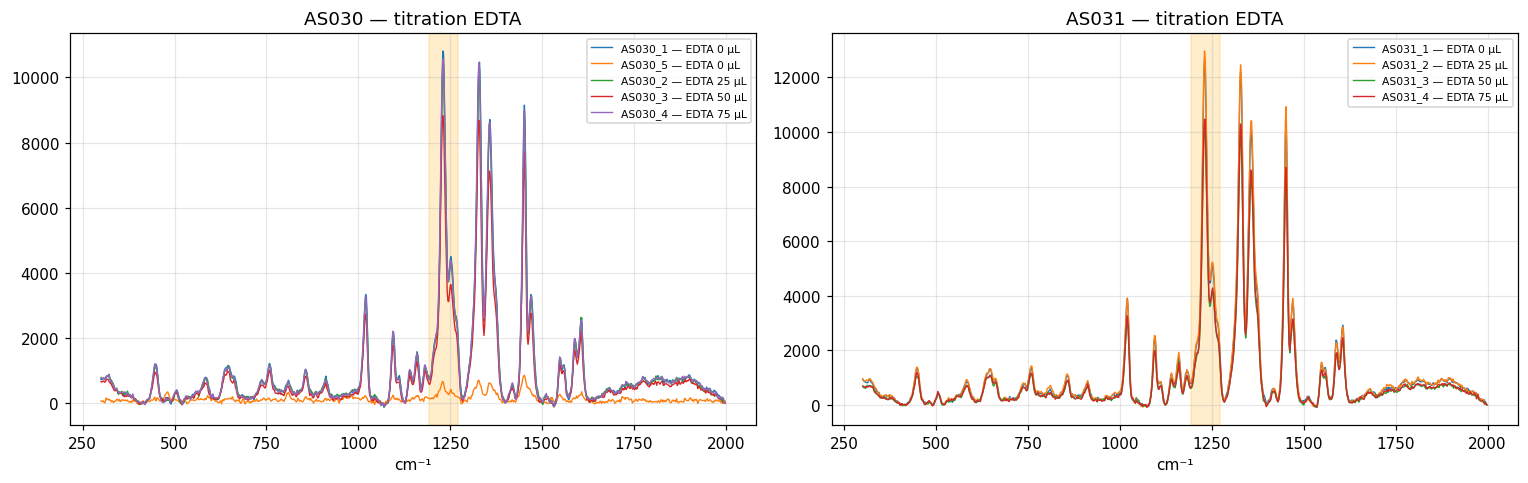

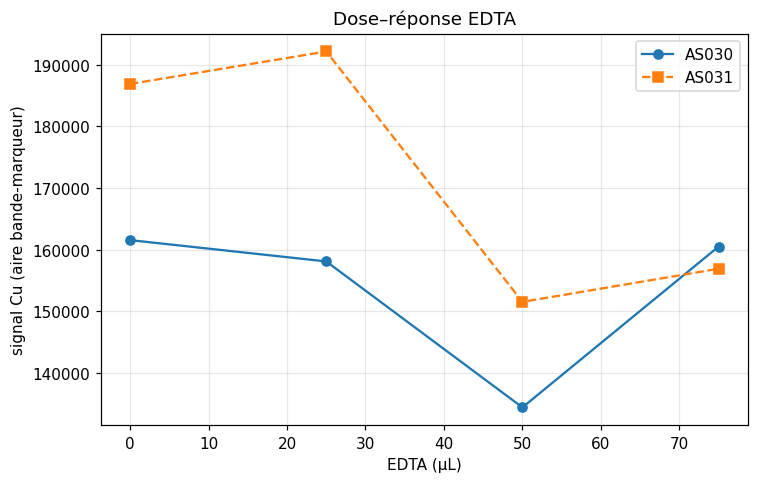

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
res = []
for ax, mp in zip(axes, ["AS030", "AS031"]):
    ids = [s for s in comp.index[comp["Feuille"] == mp] if s in S_corr.index]
    ids = sorted(ids, key=lambda s: comp.loc[s, "EDTA"])
    for sid in ids:
        ax.plot(GRID, S_corr.loc[sid], lw=.9, label=f"{sid} — EDTA {comp.loc[sid,'EDTA']:.0f} µL")
    ax.axvspan(*BAND, color='orange', alpha=.2); ax.legend(fontsize=7)
    ax.set_title(f"{mp} — titration EDTA"); ax.set_xlabel("cm⁻¹")
plt.tight_layout(); plt.show()

# dose-reponse : signal vs EDTA
plt.figure(figsize=(7, 4.5))
for mp, mk in [("AS030", "o-"), ("AS031", "s--")]:
    sub = comp[(comp["Feuille"] == mp) & comp.index.isin(S_corr.index)]
    sub = sub[sub["Ordre d'ajout"].str.contains("PEG > NP > Mg")]  # garde la sequence standard
    sub = sub.sort_values("EDTA")
    plt.plot(sub["EDTA"], sub["signal_Cu"], mk, label=mp)
plt.xlabel("EDTA (µL)"); plt.ylabel("signal Cu (aire bande-marqueur)")
plt.title("Dose–réponse EDTA"); plt.legend(); plt.tight_layout(); plt.show()

### 8.b — Quantité de Mg et de BRB (comparaisons confondues)

⚠️ Ici aucune comparaison n'est propre, on l'explicite :
- **Mg** : `AS026_1` (208 µL, **sans Cu**) vs `AS026_2` (416 µL, **avec Cu**) → le Mg
  change *en même temps* que le Cu. L'énorme écart de signal vient surtout du **Cu**, pas
  du Mg. Le nuage de points colore donc par présence de Cu pour ne pas se tromper.
- **BRB** : `AS029_3` (100 µL) vs `AS029_4` (500 µL) — déjà vu en §7.c, l'ordre **et** le
  Mg changent aussi.

À retenir : sans paire « toutes choses égales par ailleurs », on ne peut pas isoler
l'effet propre de Mg ou de BRB ici.


            Mg      Cu      signal_Cu
ID                                   
AS026_1  208.0     0.0    6239.528441
AS026_2  416.0  1000.0  137097.405342
AS026_3  208.0     0.0    6576.084657
AS026_4  416.0  1000.0  140873.731215
AS026_5  208.0     0.0    4995.733846
AS026_6  208.0     0.0    3550.558138


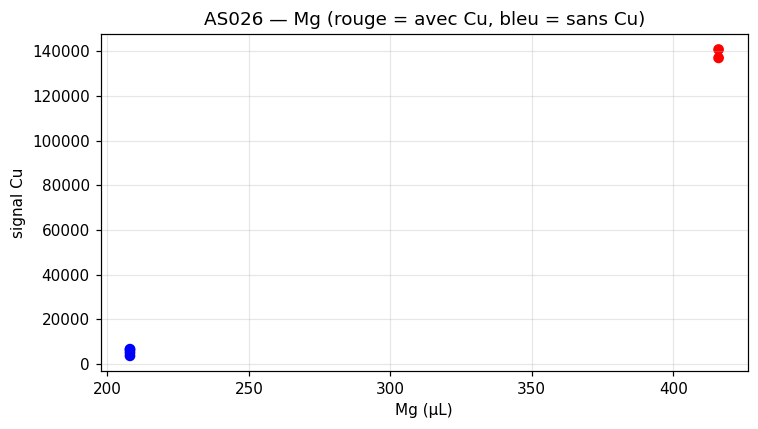

In [12]:
sub = comp.loc[["AS026_1","AS026_2","AS026_3","AS026_4","AS026_5","AS026_6"],
               ["Mg","Cu","signal_Cu"]]
print(sub.to_string())
plt.figure(figsize=(7,4))
plt.scatter(comp.loc[comp['Feuille']=='AS026','Mg'],
            comp.loc[comp['Feuille']=='AS026','signal_Cu'],
            c=comp.loc[comp['Feuille']=='AS026','a_Cu'].map({True:'r',False:'b'}))
plt.xlabel("Mg (µL)"); plt.ylabel("signal Cu")
plt.title("AS026 — Mg (rouge = avec Cu, bleu = sans Cu)")
plt.tight_layout(); plt.show()

## 9. Analyse multivariée (PCA)

**But.** Plutôt que de regarder bande par bande, la **PCA** (analyse en composantes
principales) résume *tout* le spectre en quelques axes (PC1, PC2) qui capturent le maximum
de variance. Question : **quelle variable explique les principales différences** entre
spectres ?

**Lecture.**
- Chaque **point = un échantillon** projeté sur (PC1, PC2). Deux points proches = spectres
  semblables.
- On **colore** les points par `présence de Cu` puis par `manip`. Si les couleurs se
  séparent le long d'un axe, c'est que cette variable structure les données (ex. le Cu
  domine la variance attendue).
- Les **loadings** (courbes PC1/PC2 en fonction de cm⁻¹) disent *quelles bandes* portent
  chaque axe : un pic de loading dans la fenêtre-marqueur orange confirmerait que l'axe
  est bien « piloté » par la signature cuivre.


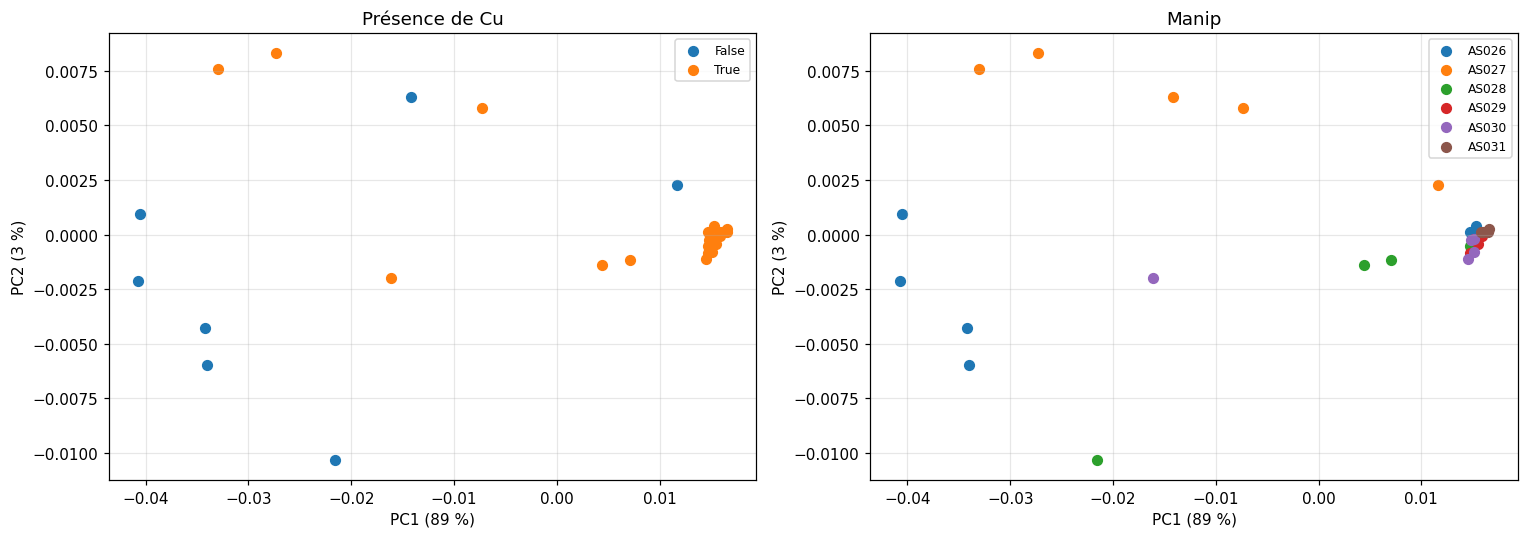

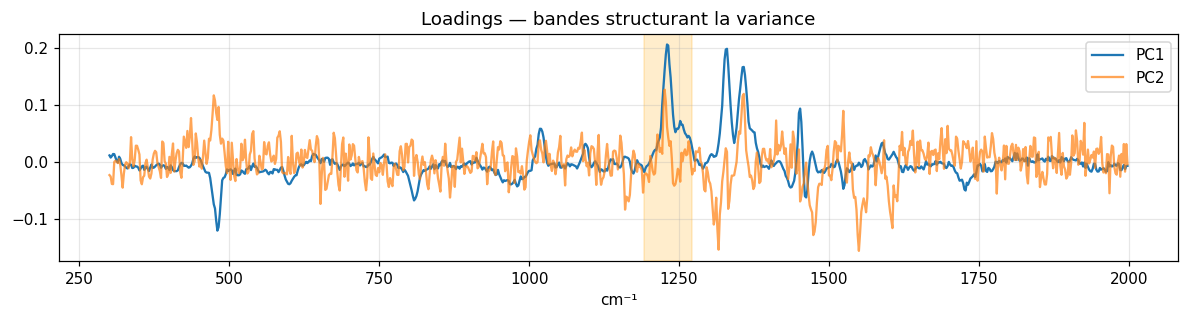

In [13]:
X = S_norm.loc[comp.index].to_numpy()
Xc = X - X.mean(0)
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
scores = U * s
ev = (s**2) / (s**2).sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col, title, ax in [("a_Cu", "Présence de Cu", axes[0]), ("Feuille", "Manip", axes[1])]:
    for val, g in comp.groupby(col):
        idx = [comp.index.get_loc(i) for i in g.index]
        ax.scatter(scores[idx, 0], scores[idx, 1], label=str(val), s=40)
    ax.set_xlabel(f"PC1 ({ev[0]:.0f} %)"); ax.set_ylabel(f"PC2 ({ev[1]:.0f} %)")
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# loadings PC1
plt.figure(figsize=(11,3))
plt.plot(GRID, Vt[0], label="PC1"); plt.plot(GRID, Vt[1], label="PC2", alpha=.7)
plt.axvspan(*BAND, color='orange', alpha=.2); plt.legend()
plt.title("Loadings — bandes structurant la variance"); plt.xlabel("cm⁻¹")
plt.tight_layout(); plt.show()

## 10. Synthèse quantitative & corrélations

**But.** Rassembler l'indicateur `signal_Cu` de tous les échantillons (trié par manip) et
mesurer sa **corrélation** avec les quantités de réactifs.

**Lecture des corrélations.** Le coefficient de Pearson `r` ∈ [−1, +1] : proche de +1 =
le signal *croît* avec la variable ; proche de −1 = il *décroît* ; proche de 0 = pas de
relation linéaire. **Calculé uniquement sur les échantillons contenant du Cu** (sinon le
contraste Cu/non-Cu écraserait tout).

> ⚠️ Ces corrélations sont calculées sur des manips hétérogènes (ordres et tampons
> différents) : elles sont **indicatives, pas causales**. Un `r` faible ou de signe
> inattendu (ex. EDTA) reflète autant les **confusions** que la chimie. Les conclusions
> fiables viennent des **paires contrôlées** (§7.a, §7.b, §8.a), pas de ces `r` globaux.


In [14]:
tab = comp[["Feuille","Ordre d'ajout","Mg","Cu","EDTA","BRB","a_Cu","signal_Cu"]].copy()
tab = tab.sort_values(["Feuille","signal_Cu"], ascending=[True, False])
display(tab.round(0))

# correlation signal vs variables (sur echantillons AVEC Cu)
cu = comp[comp["a_Cu"]]
print("\nCorrélation (Pearson) du signal_Cu avec, sur les échantillons CONTENANT du Cu :")
for v in ["EDTA", "Mg", "BRB", "Volume total"]:
    if cu[v].nunique() > 1:
        r = np.corrcoef(cu[v], cu["signal_Cu"])[0, 1]
        print(f"  {v:14s} : r = {r:+.2f}")

,Feuille,Ordre d'ajout,Mg,Cu,EDTA,BRB,a_Cu,signal_Cu
ID,,,,,,,,
AS026_4,AS026,NP > PEG > Mg > PAN > Cu > H20,416.0,1000.0,0.0,0.0,True,140874.0
AS026_2,AS026,NP > PEG > Mg > PAN > Cu > H20,416.0,1000.0,0.0,0.0,True,137097.0
AS026_3,AS026,NP > PEG > Mg > PAN > H2O,208.0,0.0,0.0,0.0,False,6576.0
AS026_1,AS026,NP > PEG > Mg > PAN > H2O,208.0,0.0,0.0,0.0,False,6240.0
AS026_5,AS026,NP > PEG > PAN > Mg > H2O,208.0,0.0,0.0,0.0,False,4996.0
AS026_6,AS026,NP > PEG > Mg > PAN > H2O,208.0,0.0,0.0,0.0,False,3551.0
AS027_3,AS027,H2O > PEG > NP > Mg > H2O,400.0,0.0,0.0,0.0,False,65279.0
AS027_5,AS027,Cu > PEG > NP > Ca > PAN > H2O,0.0,1000.0,0.0,0.0,True,15469.0
AS027_2,AS027,PEG > NP > Ca > PAN > H2O,0.0,0.0,0.0,0.0,False,12440.0



Corrélation (Pearson) du signal_Cu avec, sur les échantillons CONTENANT du Cu :
  EDTA           : r = +0.36
  Mg             : r = +0.48
  BRB            : r = +0.13
  Volume total   : r = +0.46


### Lecture des résultats — ce que disent les données

**Méthodologie à respecter pour conclure :**
1. Toujours comparer un écart au **bruit des réplicats** (§5, CV ≈ 36 % ici → exigeant).
2. Ne tirer de conclusion *causale* que des **paires contrôlées** (une seule variable change).
3. Traiter les corrélations globales (§10) comme de simples indices.

**Observations principales (à vérifier au regard des graphiques) :**
- **L'indicateur fonctionne** : avec-Cu ≈ 1·10⁵ vs sans-Cu ≈ 5·10³ → la fenêtre-marqueur
  capte bien le complexe Cu–PAN.
- **Ordre d'ajout du Cu (§7.b, AS028)** : le signal est nettement **plus fort quand le Cu
  est ajouté en fin de séquence** que tout au début → effet d'ordre *réel* et marquant
  (comparaison propre).
- **Ordre Mg/PAN (§8, AS030_1 vs AS030_5)** : inverser PAN et Mg effondre le signal →
  l'ordre d'ajout de l'indicateur est critique.
- **Titration EDTA (§8.a)** : la décroissance attendue avec l'EDTA est **faible/bruitée**
  sur la plage 0–75 µL → soit la dose est trop basse pour chélater significativement le Cu,
  soit le bruit la masque. C'est ce qui explique le `r` EDTA non négatif.
- **Confusions à ne pas sur-interpréter** : Mg vs Cu (AS026), ordre vs quantité BRB (AS029_3/4).

**Pistes pour affiner :**
- Fixer `BAND` sur une attribution Cu–PAN connue (§6) si disponible.
- Refaire des **réplicats** pour abaisser le bruit, et n'introduire qu'**une variable à la
  fois** dans les futures manips.
